# Proyecto 2 (MIMIC-III Demo) - REGRESIÓN

## Objetivo
Construir un modelo de regresión lineal para predecir icu_hours



In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

patients = pd.read_csv('PATIENTS.csv', usecols=['subject_id','gender','dob'])
adm = pd.read_csv('ADMISSIONS.csv', usecols=['subject_id','hadm_id','admittime','admission_type','insurance'])
icu = pd.read_csv('ICUSTAYS.csv', usecols=['subject_id','hadm_id','intime','outtime'])

df = adm.merge(patients, on='subject_id', how='left').merge(icu, on=['subject_id','hadm_id'], how='left')
for c in ['dob','admittime','intime','outtime']:
    df[c] = pd.to_datetime(df[c], errors='coerce')

df['age'] = ((df['admittime'] - df['dob']).dt.days / 365.25).clip(lower=0, upper=90)
df['icu_hours'] = (df['outtime'] - df['intime']).dt.total_seconds() / 3600

df = df[['age','gender','admission_type','insurance','icu_hours']].copy()
print('Dataset base listo')
df.head()


Dataset base listo


,age,gender,admission_type,insurance,icu_hours
0,70.633812,F,EMERGENCY,Medicare,39.181111
1,36.188912,F,EMERGENCY,Private,332.416667
2,87.082820,F,EMERGENCY,Medicare,63.597778
3,73.675565,F,EMERGENCY,Medicare,51.446667
4,48.898015,M,EMERGENCY,Medicare,31.052222


In [12]:
print('Shape:', df.shape)
missing = df.isnull().sum()
display(missing[missing>0].to_frame('missing_count'))


Shape: (136, 5)


,missing_count


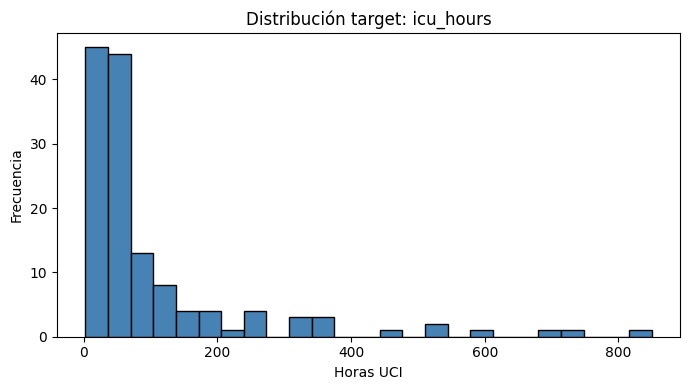

In [13]:
plt.figure(figsize=(7,4))
plt.hist(df['icu_hours'].dropna(), bins=25, color='steelblue', edgecolor='black')
plt.title('Distribución target: icu_hours')
plt.xlabel('Horas UCI')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


In [14]:
work = df.copy()
work['age'] = work['age'].fillna(work['age'].median())
work['icu_hours'] = work['icu_hours'].fillna(work['icu_hours'].median())
for col in ['gender','admission_type','insurance']:
    work[col] = work[col].fillna(work[col].mode()[0])

X_df = pd.get_dummies(work.drop(columns=['icu_hours']), drop_first=True, dtype=int)
y = work['icu_hours'].values.astype(float)
X = X_df.values.astype(float)

idx = np.random.permutation(len(X))
cut = int(0.75*len(X))
tr, te = idx[:cut], idx[cut:]
X_train, X_test = X[tr], X[te]
y_train, y_test = y[tr], y[te]

mu = X_train.mean(axis=0)
sd = X_train.std(axis=0)
sd[sd==0]=1
X_train = ((X_train-mu)/sd).astype(float)
X_test = ((X_test-mu)/sd).astype(float)

print('Train/Test:', X_train.shape, X_test.shape)


Train/Test: (102, 7) (34, 7)


In [15]:
def mse(y,p): return np.mean((y-p)**2)
def rmse(y,p): return np.sqrt(mse(y,p))
def mae(y,p): return np.mean(np.abs(y-p))
def r2(y,p):
    ss_res=np.sum((y-p)**2); ss_tot=np.sum((y-y.mean())**2)
    return 0.0 if ss_tot==0 else 1-ss_res/ss_tot

def train_linear(X,y,lr=0.01,epochs=3000,l2=1e-4,verbose_every=300):
    w=np.zeros(X.shape[1]); b=0.0
    cost=[]
    r2_hist=[]
    for epoch in range(1, epochs+1):
        pred=X@w+b
        err=pred-y
        dw=(X.T@err)/len(X)+l2*w
        db=err.mean()
        w-=lr*dw
        b-=lr*db
        cst=0.5*np.mean(err**2)+0.5*l2*np.sum(w*w)
        r2_tr=r2(y,pred)
        cost.append(cst)
        r2_hist.append(r2_tr)
        if epoch % verbose_every == 0:
            print(f'Epoch {epoch:4d} | Costo: {cst:.4f} | R2(train): {r2_tr:.4f}')
    return w,b,cost,r2_hist

w,b,cost_hist,r2_hist = train_linear(X_train,y_train,lr=0.01,epochs=3000,l2=1e-4,verbose_every=300)
p_train = X_train@w+b
p_test = X_test@w+b

print('Métricas en TEST')
print('MAE :', round(mae(y_test,p_test),4))
print('MSE :', round(mse(y_test,p_test),4))
print('RMSE:', round(rmse(y_test,p_test),4))
print('R2  :', round(r2(y_test,p_test),4))


Epoch  300 | Costo: 11501.4187 | R2(train): 0.1477
Epoch  600 | Costo: 11418.6852 | R2(train): 0.1538
Epoch  900 | Costo: 11411.3827 | R2(train): 0.1544
Epoch 1200 | Costo: 11409.9205 | R2(train): 0.1545
Epoch 1500 | Costo: 11409.1706 | R2(train): 0.1545
Epoch 1800 | Costo: 11408.5859 | R2(train): 0.1546
Epoch 2100 | Costo: 11408.0947 | R2(train): 0.1546
Epoch 2400 | Costo: 11407.6780 | R2(train): 0.1547
Epoch 2700 | Costo: 11407.3241 | R2(train): 0.1547
Epoch 3000 | Costo: 11407.0234 | R2(train): 0.1547
Métricas en TEST
MAE : 68.4545
MSE : 6030.0325
RMSE: 77.6533
R2  : -0.1416


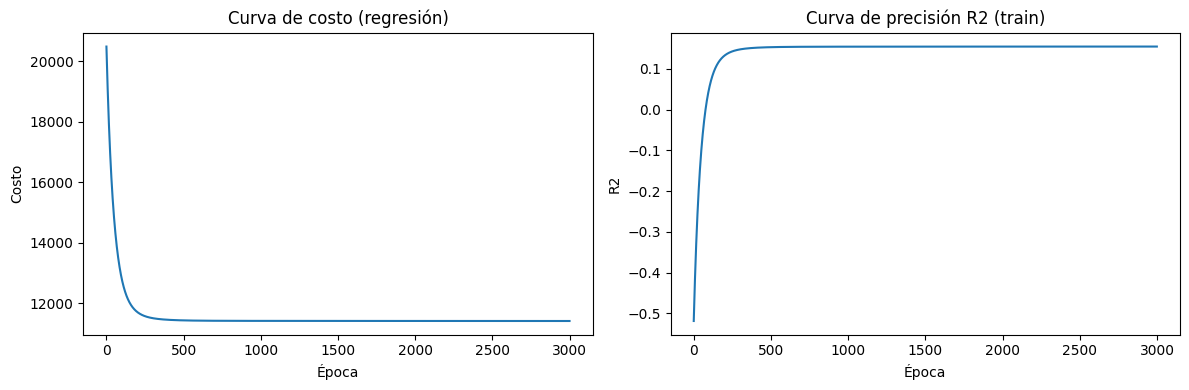

In [16]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(cost_hist)
plt.title('Curva de costo (regresión)')
plt.xlabel('Época'); plt.ylabel('Costo')

plt.subplot(1,2,2)
plt.plot(r2_hist)
plt.title('Curva de precisión R2 (train)')
plt.xlabel('Época'); plt.ylabel('R2')
plt.tight_layout(); plt.show()


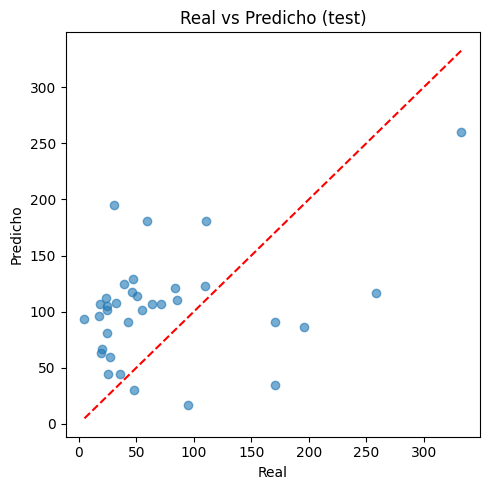

In [17]:
plt.figure(figsize=(5,5))
plt.scatter(y_test,p_test,alpha=0.6)
mn,mx=min(y_test.min(),p_test.min()),max(y_test.max(),p_test.max())
plt.plot([mn,mx],[mn,mx],'r--')
plt.title('Real vs Predicho (test)')
plt.xlabel('Real'); plt.ylabel('Predicho')
plt.tight_layout(); plt.show()


## Descripción del proceso realizado
1. Integración de fuentes clínicas (PATIENTS, ADMISSIONS, ICUSTAYS).
2. Construcción del target de regresión icu_hours.
3. Limpieza de datos e imputación de faltantes.
4. Codificación de variables categóricas y estandarización de caracteristicas.
5. Entrenamiento con descenso del gradiente y regularización L2.
6. Evaluación con MAE, MSE, RMSE, R2 y gráficos de desempeño.


## Explicación final del proyecto

- Se aplicó división 75/25 para medir generalización sobre datos no vistos.
- El grafico de distribuciion de icu_hours muestra que la mayor frecuencia esta en 0 min
- Se entrenó el modelo con descenso del gradiente, mostrando las epocas durante el entrenamiento.
- Se utilizó regularización L2 para reducir sobreajuste.
- Se evaluó el desempeño con métricas pertinentes del problema y visualizaciones de soporte.
- Las curvas permiten verificar convergencia y estabilidad del aprendizaje, como no existe la curva de presion en utilizamos el $R^2$ para poder mostrar algo similar y como se puede apreciar tenemos una gran tendencia a la alza desde la epoca 300 mas o menos y una muestra de que llego al maximo mas o menos en la epoca 2000.
